In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# cсылка на dataset https://drive.google.com/file/d/1iMNePp_UnGmrYpDg2gp7Nfnvk8I5dybF/view?usp=sharing
df = pd.read_csv('hotels_dataset.csv')

df.head(3)

,Price,City,Rating,Center_distance_km,Metro_distance_km,Review_number,Hotel_kind
0,17500,st._petersburg,9.0,0.427,0.196,119,hotel
1,2736,st._petersburg,8.6,3.800,0.406,149,hotel
2,4496,st._petersburg,9.3,2.500,0.588,119,hotel


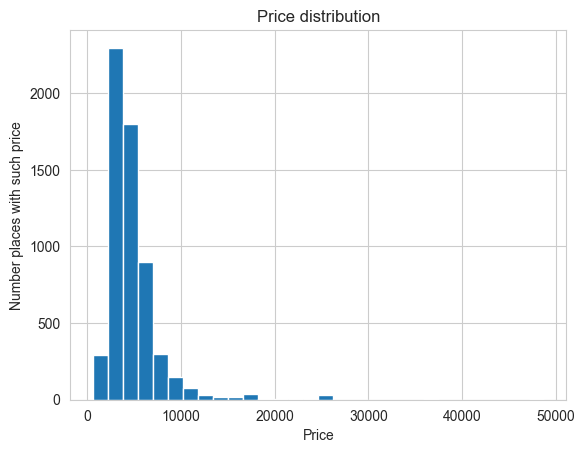

In [2]:
df[df.Price < 70000].Price.hist(bins=30)
plt.xlabel('Price')
plt.ylabel('Number places with such price')
plt.title('Price distribution')
plt.show()

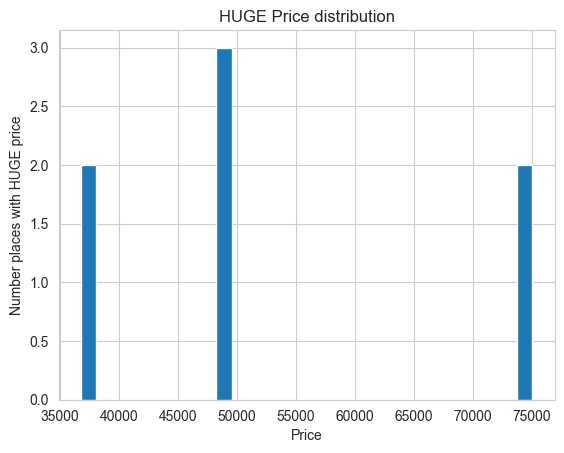

In [3]:
df[df.Price > 30000].Price.hist(bins=30)
plt.xlabel('Price')
plt.ylabel('Number places with HUGE price')
plt.title('HUGE Price distribution')
plt.show()

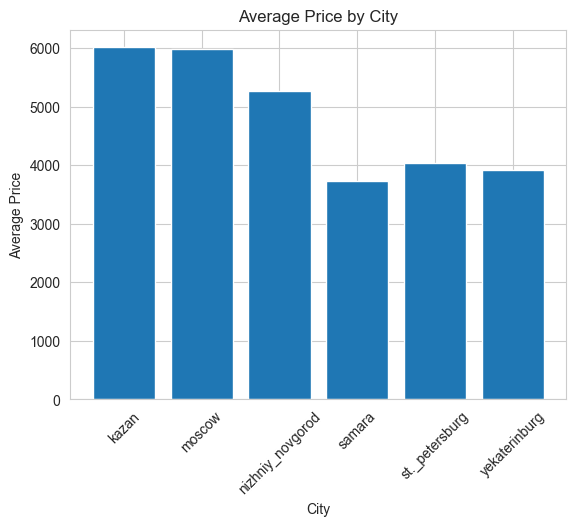

In [4]:
avg_city_prices = df[['Price', 'City']].groupby('City').mean('Price').reset_index()
plt.bar(avg_city_prices.City, avg_city_prices.Price)
plt.xlabel('City')
plt.ylabel('Average Price')
plt.title('Average Price by City')
plt.xticks(rotation=45)
plt.show()

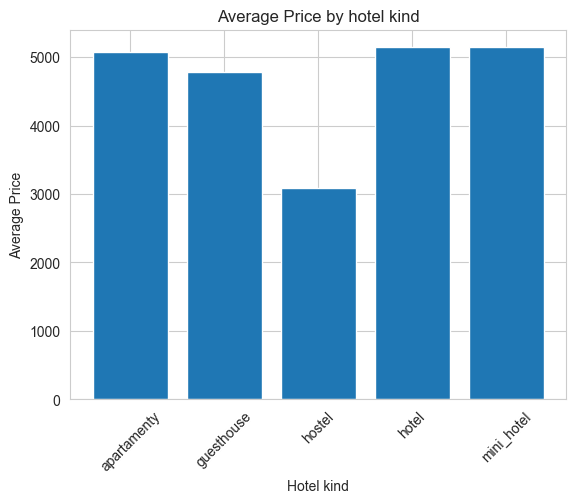

In [5]:
avg_hkind_prices = df[['Price', 'Hotel_kind']].groupby('Hotel_kind').mean('Price').reset_index()
plt.bar(avg_hkind_prices.Hotel_kind, avg_hkind_prices.Price)
plt.xlabel('Hotel kind')
plt.ylabel('Average Price')
plt.title('Average Price by hotel kind')
plt.xticks(rotation=45)
plt.show()

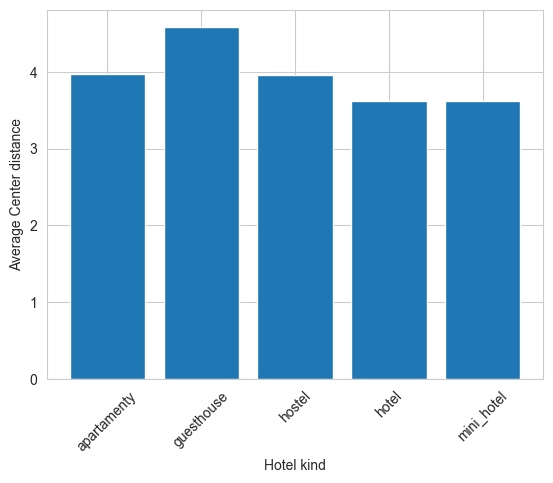

In [6]:
avg_hkind_center_distances = df[['Center_distance_km', 'Hotel_kind']].groupby('Hotel_kind').mean('Center_distance_km').reset_index()
plt.bar(avg_hkind_center_distances.Hotel_kind, avg_hkind_center_distances.Center_distance_km)
plt.xlabel('Hotel kind')
plt.ylabel('Average Center distance')
plt.xticks(rotation=45)
plt.show()

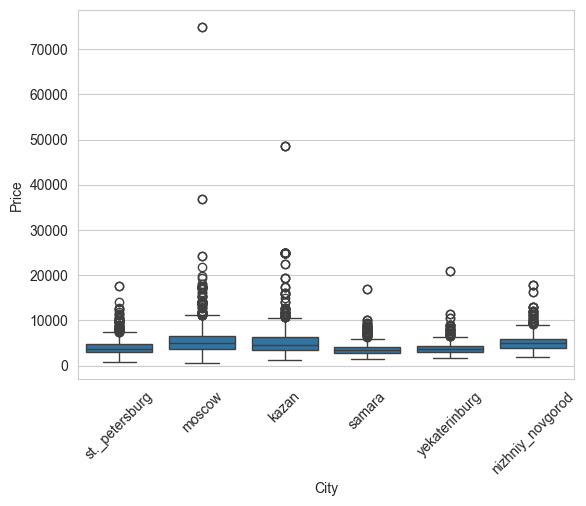

In [7]:
sns.boxplot(x=df.City, y=df.Price, data=df[['Price', 'City']])
plt.xticks(rotation=45)
plt.show()

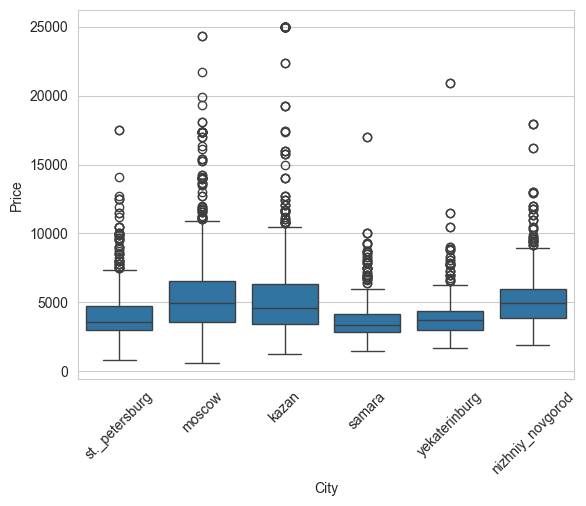

In [8]:
price_border = 30000
sns.boxplot(x=df.City, y=df.Price.loc[df.Price < price_border], data=df[['Price', 'City']].loc[df.Price < price_border])
plt.xticks(rotation=45)
plt.show()

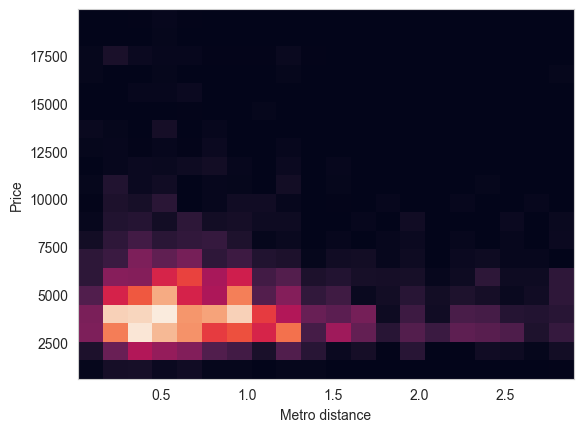

In [9]:
metro_distance_border = 3
price_border = 20000
plt.hist2d(df.Metro_distance_km.loc[(df.Metro_distance_km < metro_distance_border) & (df.Price < price_border)], df.Price.loc[(df.Metro_distance_km < metro_distance_border) & (df.Price < price_border)], bins=20)
plt.xlabel('Metro distance')
plt.ylabel('Price')
plt.show()

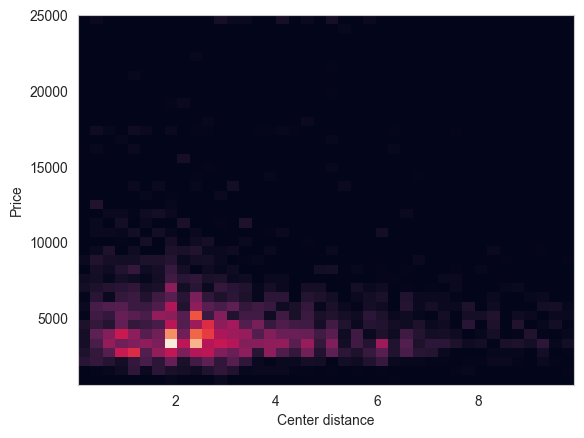

In [10]:
center_distance_border = 10
price_border = 30000
plt.hist2d(df.Center_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Price < price_border)], df.Price.loc[(df.Center_distance_km < center_distance_border) & (df.Price < price_border)], bins = 40)
plt.xlabel('Center distance')
plt.ylabel('Price')
plt.show()

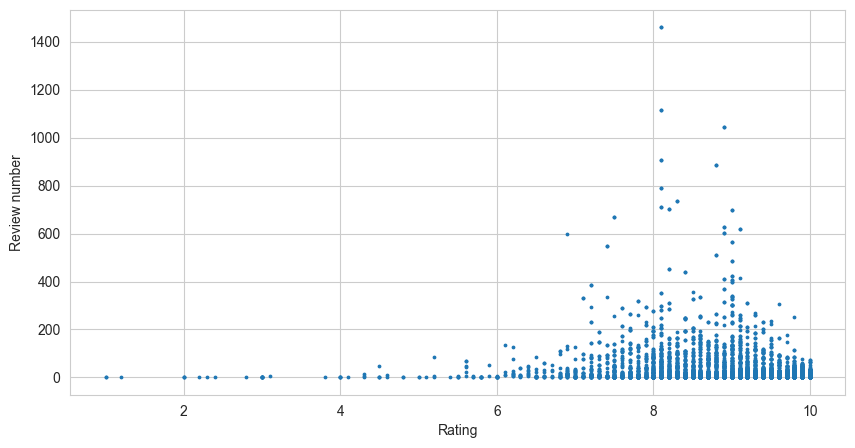

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(df.Rating, df.Review_number, s = 3)
plt.xlabel('Rating')
plt.ylabel('Review number')

plt.show()

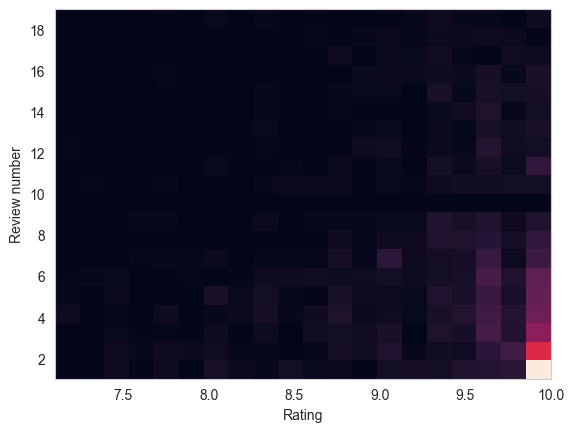

In [12]:
rating_border = 7
review_number_border = 20
plt.hist2d(df.Rating.loc[(df.Rating > rating_border) & (df.Review_number < review_number_border)], df.Review_number.loc[(df.Rating > rating_border) & (df.Review_number < review_number_border)], bins = 20)
plt.xlabel('Rating')
plt.ylabel('Review number')
plt.show()

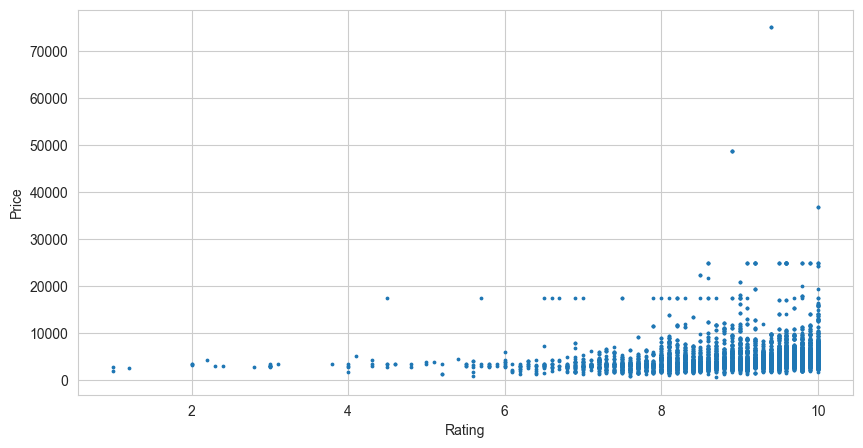

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(df.Rating, df.Price, s = 3)
plt.xlabel('Rating')
plt.ylabel('Price')

plt.show()

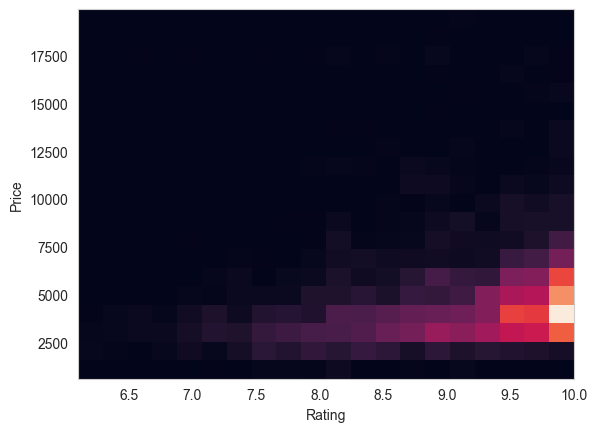

In [14]:
rating_border = 6
price_border = 20000
plt.hist2d(df.Rating.loc[(df.Rating > rating_border) & ( df.Price< price_border)], df.Price.loc[(df.Rating > rating_border) & ( df.Price< price_border) ], bins = 20)
plt.xlabel('Rating')
plt.ylabel('Price')
plt.show()

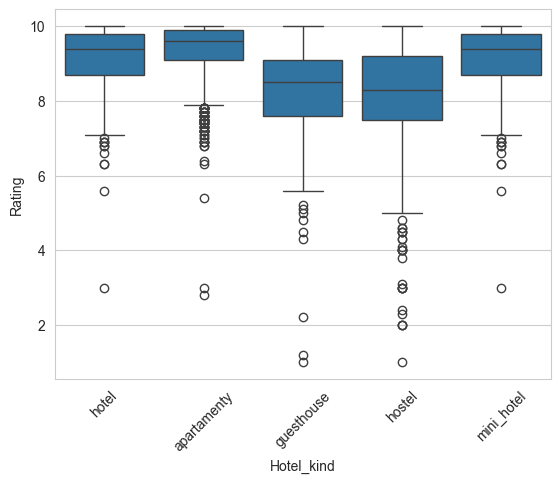

In [15]:
sns.boxplot(x=df.Hotel_kind, y=df.Rating, data=df[['Rating', 'Hotel_kind']])
plt.xticks(rotation=45)
plt.show()

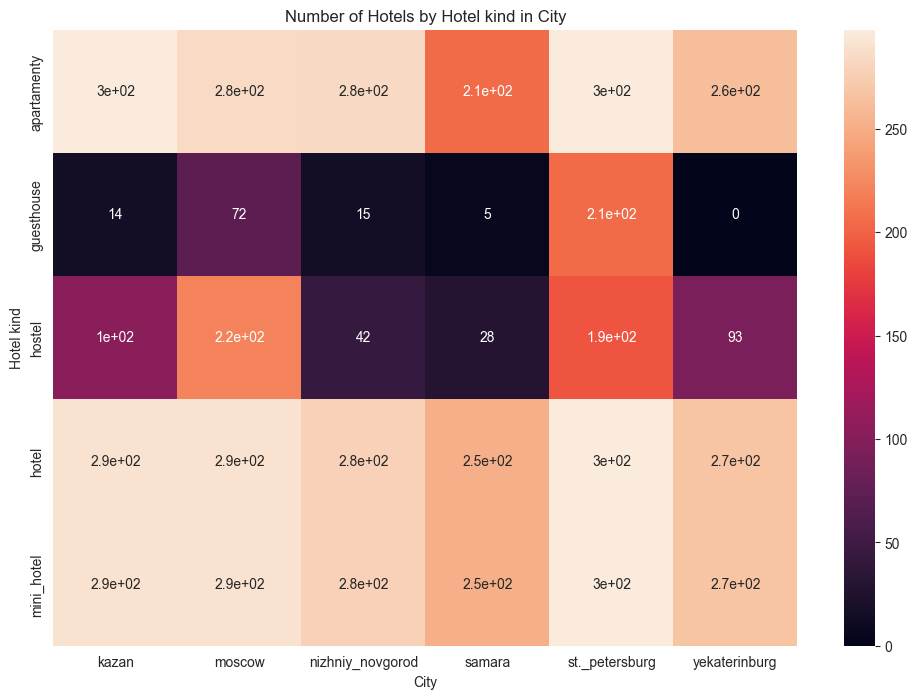

In [16]:
hotel_counts = df.groupby(['City', 'Hotel_kind']).size().reset_index(name='Count')

# Преобразование данных в формат сводной таблицы
pivot_table = hotel_counts.pivot_table(index='Hotel_kind', columns='City', values='Count', fill_value=0)

# Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True)
plt.xlabel('City')
plt.ylabel('Hotel kind')
plt.title('Number of Hotels by Hotel kind in City')
plt.show()

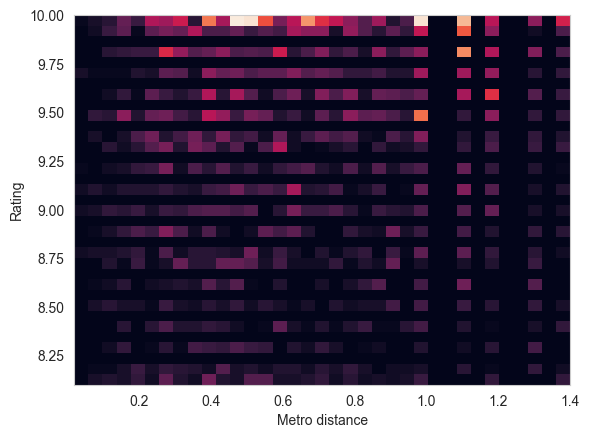

In [17]:
metro_distance_border = 1.5
rating_border = 8
plt.hist2d(df.Metro_distance_km.loc[(df.Metro_distance_km < metro_distance_border) & (df.Rating > rating_border)], df.Rating.loc[(df.Metro_distance_km < metro_distance_border) & (df.Rating > rating_border)], bins=35)
plt.xlabel('Metro distance')
plt.ylabel('Rating')
plt.show()

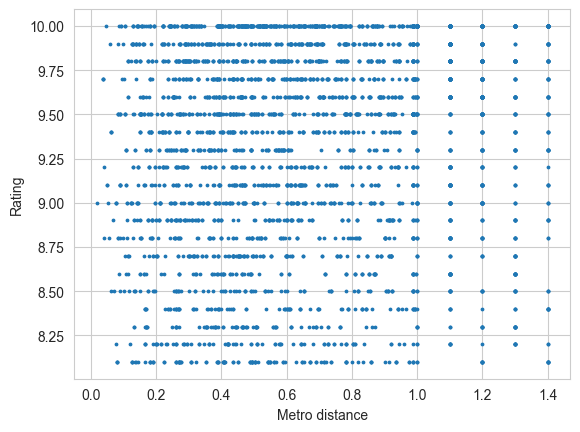

In [18]:
plt.scatter(df.Metro_distance_km.loc[(df.Metro_distance_km < metro_distance_border) & (df.Rating > rating_border)], df.Rating.loc[(df.Metro_distance_km < metro_distance_border) & (df.Rating > rating_border)], s = 3)
plt.xlabel('Metro distance')
plt.ylabel('Rating')

plt.show()

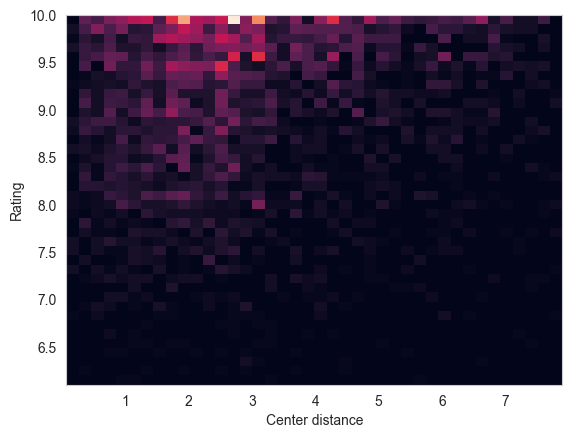

In [19]:
center_distance_border = 8
rating_border = 6
plt.hist2d(df.Center_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Rating > rating_border)], df.Rating.loc[(df.Center_distance_km < center_distance_border) & (df.Rating > rating_border)], bins=40)
plt.xlabel('Center distance')
plt.ylabel('Rating')
plt.show()


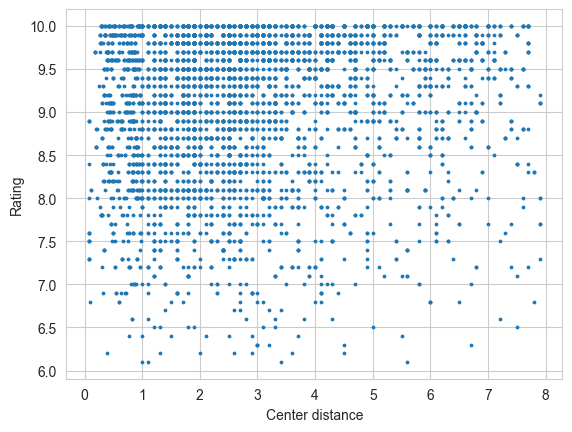

In [20]:
plt.scatter(df.Center_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Rating > rating_border)], df.Rating.loc[(df.Center_distance_km < center_distance_border) & (df.Rating > rating_border)], s = 3)
plt.xlabel('Center distance')
plt.ylabel('Rating')

plt.show()

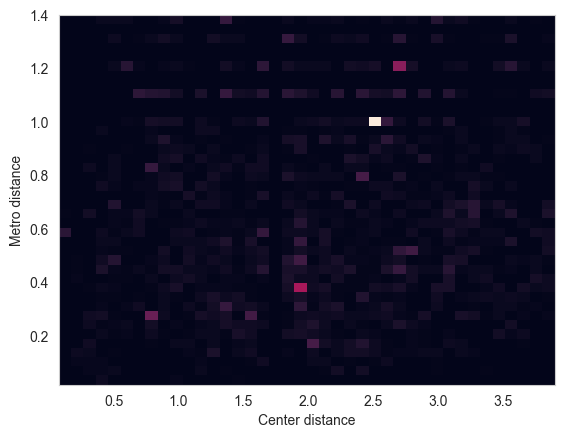

In [21]:
center_distance_border = 4
metro_distance_border = 1.5
plt.hist2d(df.Center_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Metro_distance_km < metro_distance_border)], df.Metro_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Metro_distance_km < metro_distance_border)], bins=40)
plt.xlabel('Center distance')
plt.ylabel('Metro distance')
plt.show()


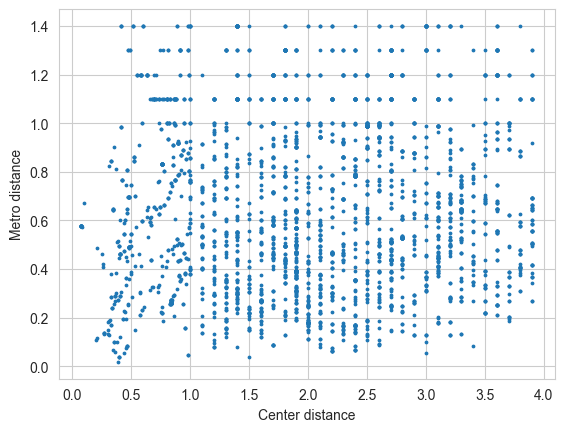

In [22]:
plt.scatter(df.Center_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Metro_distance_km < metro_distance_border)], df.Metro_distance_km.loc[(df.Center_distance_km < center_distance_border) & (df.Metro_distance_km < metro_distance_border)], s = 3)
plt.xlabel('Center distance')
plt.ylabel('Metro distance')

plt.show()

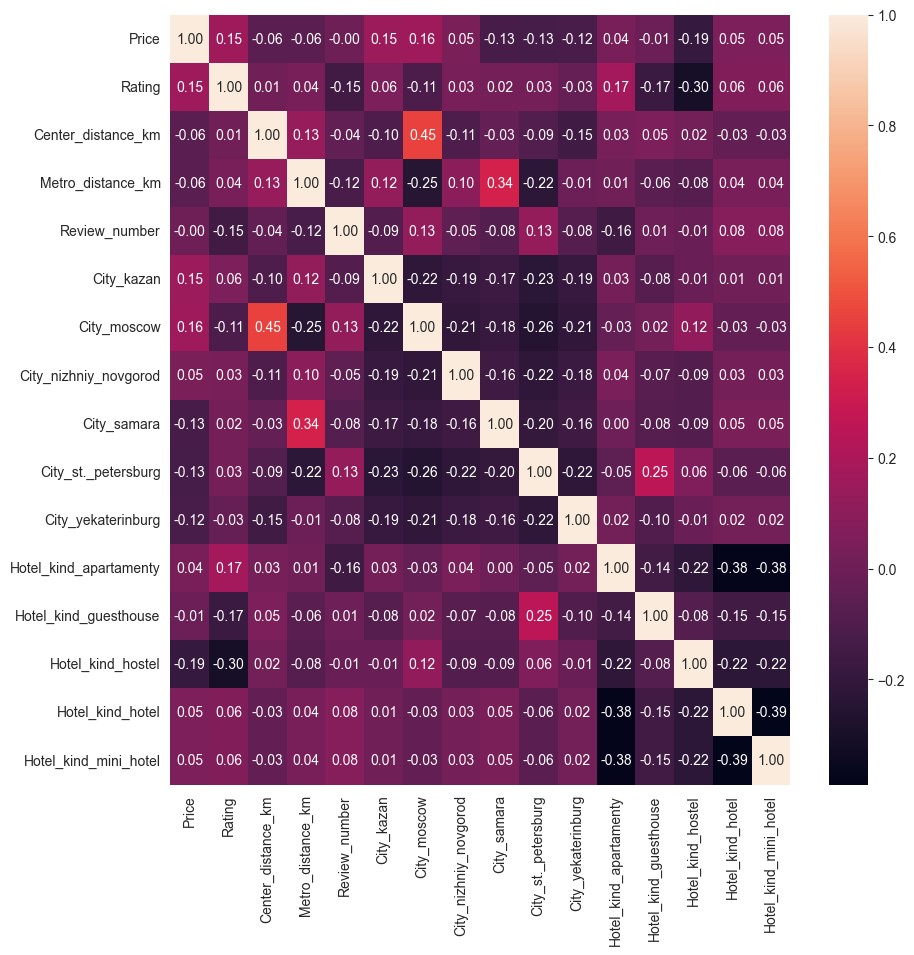

In [23]:
df_for_corr = pd.get_dummies(df).astype(int)
corr = df_for_corr.corr()
plt.figure(figsize=(10, 10))
heatmap = sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

In [24]:
# preprocessing 1 (выбросы и отсутствующие значения)

# cудя по гистограмме HUGE Price distribution, выбросы Price > 30000 имеются только у нескольких отелей. Поэтому удалим их
df = df.loc[df.Price < 30000]
print(df.isnull().values.any()) # False => отсутствующих значений нет в датасете

False


In [25]:
# baseline (по графикам видно, что в среднем больше всего с ценой коррелирует City, поэтому цену отеля будем выдавать как среднее значение группы City, в которую отель попадает)

group_mean_prices = df.groupby(['City'])['Price'].mean()

def predict(X):
    y_pred = []
    for i in range(len(X)):
        city = X.iloc[i]['City']
        y_pred.append(group_mean_prices.loc[city])

    return y_pred


In [26]:
# метрики baseline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

df['stratify_column'] = df['City'] + '_' + df['Hotel_kind']

X = df.drop(columns=['Price'], axis=1)
y = df.Price


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=X['stratify_column'])
X_train.drop(columns=['stratify_column'], axis=1, inplace=True)
X_test.drop(columns=['stratify_column'], axis=1, inplace=True)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)



y_train_pred = predict(X_train)
y_test_pred = predict(X_test)

mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
smape = 100.0 * np.mean(np.abs(y_train_pred - y_train) / (np.abs(y_train) + np.abs(y_train_pred)))

print("TRAIN metrics")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"SMAPE: {smape:.2f}%")

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
smape = 100.0 * np.mean(np.abs(y_test_pred - y_test) / (np.abs(y_test) + np.abs(y_test_pred)))

print("\nTEST metrics")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"SMAPE: {smape:.2f}%")


TRAIN metrics
MAE: 1633.87
MSE: 7275047.01
SMAPE: 15.67%

TEST metrics
MAE: 1666.91
MSE: 7406202.79
SMAPE: 16.14%


In [27]:
# реализация из  sklearn

from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# preprocessing 2 (преобразуем категориальные признаки)
X_train = pd.get_dummies(X_train).astype(int)
X_test = pd.get_dummies(X_test).astype(int)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

model = SGDRegressor()

# Подбор гиперпараметров

param_grid = {
    'loss': ['squared_error', 'huber', 'epsilon_insensitive'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],  # Коэффициент регуляризации
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.01, 0.1, 1.0],  # Начальная скорость обучения
}


hyperparams_setting = GridSearchCV(
    model,
    param_grid,
    cv=4,
    n_jobs=-1
)
hyperparams_setting.fit(X_train, y_train)
model_with_best_hparams = hyperparams_setting.best_estimator_
print("Best params: {}".format(hyperparams_setting.best_params_))

y_train_pred = model_with_best_hparams.predict(X_train)
y_test_pred = model_with_best_hparams.predict(X_test)


mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
smape = 100.0 * np.mean(np.abs(y_train_pred - y_train) / (np.abs(y_train) + np.abs(y_train_pred)))

print("TRAIN metrics")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"SMAPE: {smape:.2f}%")

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
smape = 100.0 * np.mean(np.abs(y_test_pred - y_test) / (np.abs(y_test) + np.abs(y_test_pred)))

print("\nTEST metrics")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"SMAPE: {smape:.2f}%")

Best params: {'alpha': 0.001, 'eta0': 0.01, 'learning_rate': 'invscaling', 'loss': 'squared_error', 'penalty': 'l1'}
TRAIN metrics
MAE: 1475.58
MSE: 6439605.38
SMAPE: 14.41%

TEST metrics
MAE: 1528.85
MSE: 6762801.28
SMAPE: 14.93%


In [28]:
# Собственная реализация SGD

class MySGD:

    def __init__(
    self,
    lr = 1,
    max_steps = 100000,
    l1_coeff = 0.001,
    l2_coeff = 0.01
    ):
        self.lr = lr
        self.max_steps = max_steps
        self.l1_coeff = l1_coeff
        self.l2_coeff = l2_coeff

        self.w = None

        self.mse_list = []
        self.mae_list = []
        self.smape_list = []

    def calculate_grad_w(self, X_i, y_i):
        self.w = np.array(self.w)
        X_i = np.array(X_i)

        l = X_i.shape[0]
        grad = []

        for j in range(0, l):
            grad.append(2*X_i[j]*(np.dot(X_i, self.w) - y_i))
        grad += self.l1_coeff * np.sign(self.w) + 2 * self.l2_coeff * self.w

        return grad

    def fit(self, X, y):
        X = np.concatenate((np.ones((X.shape[0],1)),X),axis=1) # добавим единичный столбец (intercept)

        l, f = X.shape
        self.w = np.zeros(f)
        y = y.values
        epoch = 0
        while epoch < self.max_steps:
            random_i = np.random.randint(l)

            X_i = X[random_i]
            y_i = y[random_i]
            self.w = self.w - self.lr/l * self.calculate_grad_w(X_i, y_i)
            y_pred = self.predict_inner(X)

            mae = mean_absolute_error(y, y_pred)
            mse = mean_squared_error(y, y_pred)
            smape = 100.0 * np.mean(np.abs(y_pred - y) / (np.abs(y) + np.abs(y_pred)))
            self.mse_list.append(mse)
            self.mae_list.append(mae)
            self.smape_list.append(smape)

            epoch+=1

        return self

    def predict_inner(self, X): # не добавляем единичный столбец, т.к он уже добавлен
        return np.dot(X, self.w)

    def predict(self, X):
        X = np.concatenate((np.ones((X.shape[0],1)),X),axis=1) # добавим единичный столбец (intercept)
        return np.dot(X, self.w)


In [29]:
# подбор гиперпараметров

l1_variants = [0, 1.5]
l2_variants = [0, 1.5]
lr_variants = [0.1, 1, 1.5]
max_steps_variants = [1000, 5000, 10000]

def cross_validation(l1, l2, lr, max_steps, cv):
    l = X_train.shape[0]
    fold_size = l // cv
    mae_sum = 0

    for fold in range(cv):
        model_variant = MySGD(lr=lr, max_steps=max_steps, l1_coeff=l1, l2_coeff=l2)

        val_start_index = fold * fold_size
        val_end_index = val_start_index + fold_size if fold != cv - 1 else l
        val_indexes = np.arange(val_start_index, val_end_index)
        train_indexes = np.concatenate([np.arange(0, val_start_index), np.arange(val_end_index, l)])

        X_train_fold = X_train[train_indexes]
        y_train_fold = y_train[train_indexes]
        X_val_fold = X_train[val_indexes]
        y_val_fold = y_train[val_indexes]

        model_variant.fit(X_train_fold, y_train_fold)

        y_pred = model_variant.predict(X_val_fold)
        mae = mean_absolute_error(y_val_fold, y_pred)
        mae_sum += mae

    return mae_sum / cv


best_mae = float('inf')
best_params = {}
for l1 in l1_variants:
    for l2 in l2_variants:
        for lr in lr_variants:
            for max_steps in max_steps_variants:
                mae = cross_validation(l1, l2, lr, max_steps, 4)
                if mae < best_mae:
                    best_mae = mae
                    best_params = {
                        'l1_coeff': l1,
                        'l2_coeff': l2,
                        'lr': lr,
                        'max_steps': max_steps
                    }
print("Best_params = ", best_params)

Best_params =  {'l1_coeff': 0, 'l2_coeff': 0, 'lr': 1, 'max_steps': 5000}


In [30]:
my_best_model = MySGD(l1_coeff=best_params['l1_coeff'], l2_coeff=best_params['l2_coeff'], lr=best_params['lr'], max_steps=best_params['max_steps'])
my_best_model.fit(X_train, y_train)

y_train_pred = my_best_model.predict(X_train)
y_test_pred = my_best_model.predict(X_test)


mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
smape = 100.0 * np.mean(np.abs(y_train_pred - y_train) / (np.abs(y_train) + np.abs(y_train_pred)))

print("TRAIN metrics")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"SMAPE: {smape:.2f}%")

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
smape = 100.0 * np.mean(np.abs(y_test_pred - y_test) / (np.abs(y_test) + np.abs(y_test_pred)))

print("\nTEST metrics")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"SMAPE: {smape:.2f}%")



TRAIN metrics
MAE: 1428.18
MSE: 6688081.15
SMAPE: 14.06%

TEST metrics
MAE: 1466.53
MSE: 6924123.71
SMAPE: 14.45%


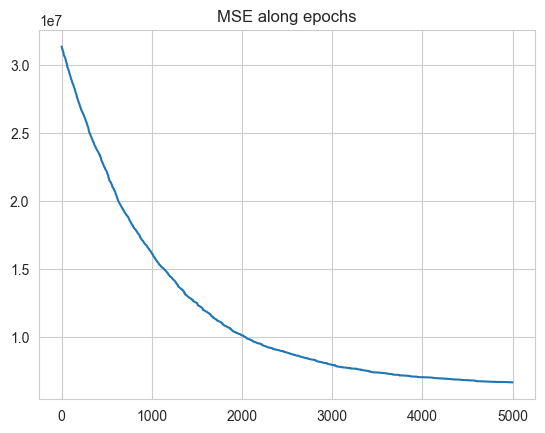

In [31]:
plt.plot(my_best_model.mse_list)
plt.title('MSE along epochs')
plt.show()

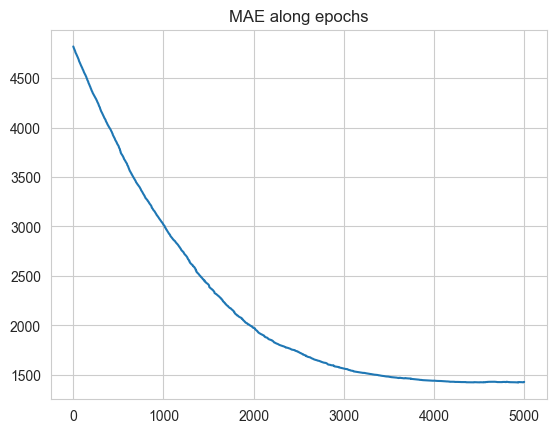

In [32]:
plt.plot(my_best_model.mae_list)
plt.title('MAE along epochs')
plt.show()

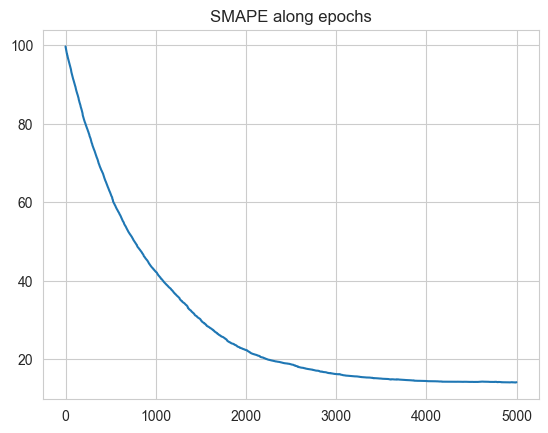

In [33]:
plt.plot(my_best_model.smape_list)
plt.title('SMAPE along epochs')
plt.show()